# Évaluation CL — K-Means (non-supervisé) — Dataset 2 Equipment Monitoring — by_equipment

| Champ | Valeur |
|-------|--------|
| **Modèle** | K-Means (détection d'anomalie, non-supervisé) |
| **Dataset** | equipment_anomaly_data.csv — 7 672 échantillons |
| **Scénario** | by_equipment : Pump → Turbine → Compressor (3 tâches) |
| **Expérience** | exp_005 — voir experiments/exp_005_unsupervised_monitoring_by_equipment/config_snapshot.yaml |
| **Date** | {date d'exécution} |

> **Modèle non-supervisé** : K-Means ne reçoit pas les labels à l'entraînement.  
> L'AUROC est la métrique principale pour évaluer la détection d'anomalie.  
> Les prédictions sont obtenues par seuillage de la distance minimale au centroïde le plus proche (seuil optimal Youden J).

In [ ]:
# Section 1 — Setup & imports
import json
import os
import pickle
import sys
from datetime import date
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

# --- CWD navigation : notebook 3 niveaux de profondeur ---
_cwd = Path(".").resolve()
if _cwd.name == "monitoring_by_equipment":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.plots import (
    plot_accuracy_matrix,
    plot_confusion_matrix_grid,
    plot_forgetting_curve,
    plot_roc_curves_per_task,
    save_figure,
)
from src.evaluation.feature_space_plots import plot_clustering_with_correctness

EXP_DIR     = Path("experiments/exp_030_kmeans_monitoring_by_equipment/results")
FIGURES_DIR = Path("notebooks/figures/cl_evaluation/kmeans/monitoring/by_equipment")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH        = Path("data/raw/equipment_monitoring/Industrial_Equipment_Monitoring_Dataset/equipment_anomaly_data.csv")
NORMALIZER_PATH = Path("configs/monitoring_normalizer.yaml")

TASK_NAMES   = ["Pump", "Turbine", "Compressor"]
MODEL_NAME   = "KMeans"
METRICS_FILE = "metrics_kmeans_dataset2.json"

print(f"Date d'exécution : {date.today()}")
print(f"REPO_ROOT  : {REPO_ROOT}")
print(f"EXP_DIR    : {EXP_DIR.resolve()}")
print(f"FIGURES_DIR: {FIGURES_DIR.resolve()}")

## Section 2 — Chargement des résultats pré-calculés

In [ ]:
metrics_path    = EXP_DIR / METRICS_FILE
acc_matrix_path = EXP_DIR / "acc_matrix_kmeans_dataset2.npy"

raw = json.loads(metrics_path.read_text())
# Structure plate depuis run_model() — pas de clé intermédiaire "cl_metrics"
mem = raw["memory"]

acc_matrix_np = np.array(
    [[v if v is not None else np.nan for v in row] for row in raw["acc_matrix"]],
    dtype=float,
)

print(f"AA       = {raw['aa']:.4f}")
print(f"AF       = {raw['af']:.4f}")
print(f"BWT      = {raw['bwt']:.4f}")
print(f"AUROC    = {raw['auroc_avg']:.4f}")
print(f"RAM      = {mem['ram_peak_bytes']} B  ({mem['ram_peak_bytes']/1024:.2f} Ko)")
print(f"Latence  = {mem['inference_latency_ms']:.5f} ms")
print(f"\nacc_matrix shape: {acc_matrix_np.shape}")
print(acc_matrix_np)

## Section 3 — Matrice d'accuracy (heatmap)

acc_matrix[i, j] = accuracy sur la tâche j après entraînement sur les tâches 0..i.  
Note : accuracy calculée par seuillage du score d'anomalie (distance minimale au centroïde).

[plots] Figure saved → notebooks/figures/cl_evaluation/kmeans/monitoring/by_equipment/acc_matrix.png


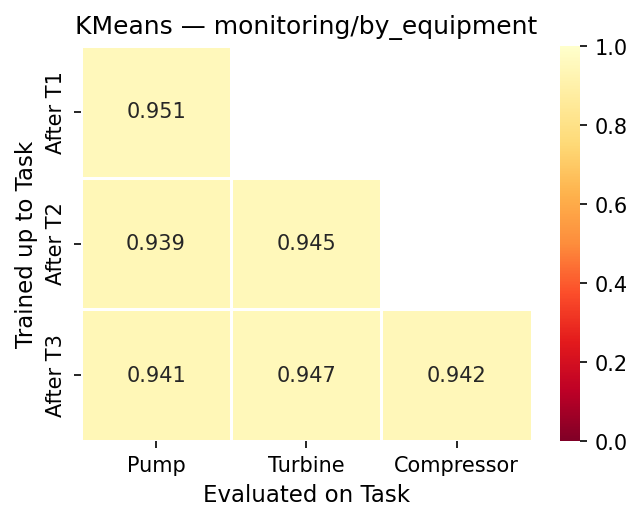

In [ ]:
fig = plot_accuracy_matrix(
    acc_matrix_np,
    task_names=TASK_NAMES,
    title=f"{MODEL_NAME} — monitoring/by_equipment",
)
save_figure(fig, FIGURES_DIR / "acc_matrix.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "acc_matrix.png")))

## Section 4 — Courbe d'oubli par tâche

AF (Average Forgetting) attendu ≈ 0.0049 — K-Means présente peu d'oubli catastrophique.

[plots] Figure saved → notebooks/figures/cl_evaluation/kmeans/monitoring/by_equipment/forgetting_curve.png


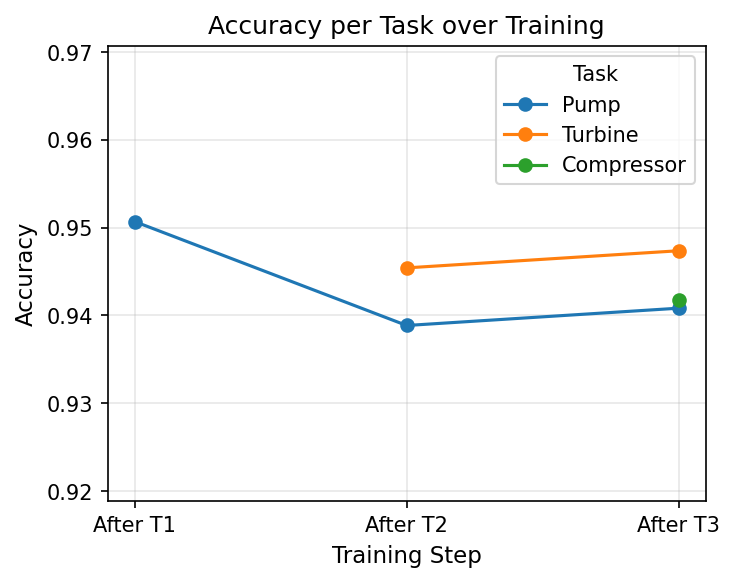

In [ ]:
fig = plot_forgetting_curve(acc_matrix_np, task_names=TASK_NAMES)
save_figure(fig, FIGURES_DIR / "forgetting_curve.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "forgetting_curve.png")))

## Section 5 — Inférence avec les checkpoints intermédiaires

Charge un checkpoint par tâche d'entraînement depuis `experiments/exp_005.../checkpoints/`.  
Pour chaque step `i`, évalue le modèle sur toutes les tâches vues `j ≤ i`.  
Construit `preds_dict[(i, j)]` complet → grille T×T en Section 6.

> **Prérequis** : relancer `scripts/train_unsupervised.py --model kmeans` si `checkpoints/` est absent.

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score

from src.data.monitoring_dataset import get_cl_dataloaders

CHECKPOINTS_DIR = EXP_DIR.parent / "checkpoints"
DATASET_TAG     = "dataset2"

# Charger le dataset
cl_tasks = get_cl_dataloaders(
    CSV_PATH, NORMALIZER_PATH, batch_size=256, seed=42
)

T = len(TASK_NAMES)

# Pré-extraction validation (évite de répéter l'itération DataLoader)
val_data = []
for task in cl_tasks:
    Xb, yb = [], []
    for X_batch, y_batch in task["val_loader"]:
        Xb.append(X_batch.numpy())
        yb.append(y_batch.numpy())
    val_data.append((np.concatenate(Xb), np.concatenate(yb).ravel()))

preds_dict  = {}   # dict[tuple[int,int], tuple[np.ndarray, np.ndarray]]
scores_dict = {}   # dict[tuple[int,int], np.ndarray]

# Pour chaque checkpoint i, évaluer sur toutes les tâches vues j <= i
for i in range(T):
    ckpt_path = CHECKPOINTS_DIR / f"kmeans_{DATASET_TAG}_task{i}.pkl"
    with open(ckpt_path, "rb") as f:
        kmeans_i = pickle.load(f)

    print(f"\nCheckpoint task{i} ({ckpt_path.name})")
    print(f"  k_selected_ : {kmeans_i.k_selected_}  |  threshold_ : {kmeans_i.threshold_:.4f}")

    for j in range(i + 1):
        X_val, y_val = val_data[j]
        scores = kmeans_i.anomaly_score(X_val)
        y_pred = kmeans_i.predict(X_val)

        preds_dict[(i, j)]  = (y_val, y_pred)
        scores_dict[(i, j)] = scores

        acc_j   = accuracy_score(y_val, y_pred)
        auroc_j = roc_auc_score(y_val, scores) if len(np.unique(y_val)) >= 2 else float("nan")
        print(f"  Eval {TASK_NAMES[j]:12s} | N={len(y_val):4d} | acc={acc_j:.4f} | AUROC={auroc_j:.4f}")

# Modèle final (task T-1) — utilisé dans Section 7/8
with open(CHECKPOINTS_DIR / f"kmeans_{DATASET_TAG}_task{T - 1}.pkl", "rb") as f:
    kmeans_det = pickle.load(f)

# Données tâche finale pour visualisations Section 7/8
X_tasks, y_true_tasks, y_pred_tasks, cluster_tasks = [], [], [], []
for j in range(T):
    X_val, y_val = val_data[j]
    X_tasks.append(X_val)
    y_true_tasks.append(y_val)
    y_pred_tasks.append(kmeans_det.predict(X_val))
    cluster_tasks.append(kmeans_det.kmeans_.predict(X_val))

print(f"\npreds_dict clés : {sorted(preds_dict.keys())}")

## Section 6 — Matrices de confusion par tâche (détection d'anomalie)

Chaque panneau correspond à une tâche évaluée avec le modèle final.  
Les matrices sont normalisées par ligne (recall par classe).

[plots] Figure saved → notebooks/figures/cl_evaluation/kmeans/monitoring/by_equipment/confusion_matrix_grid.png


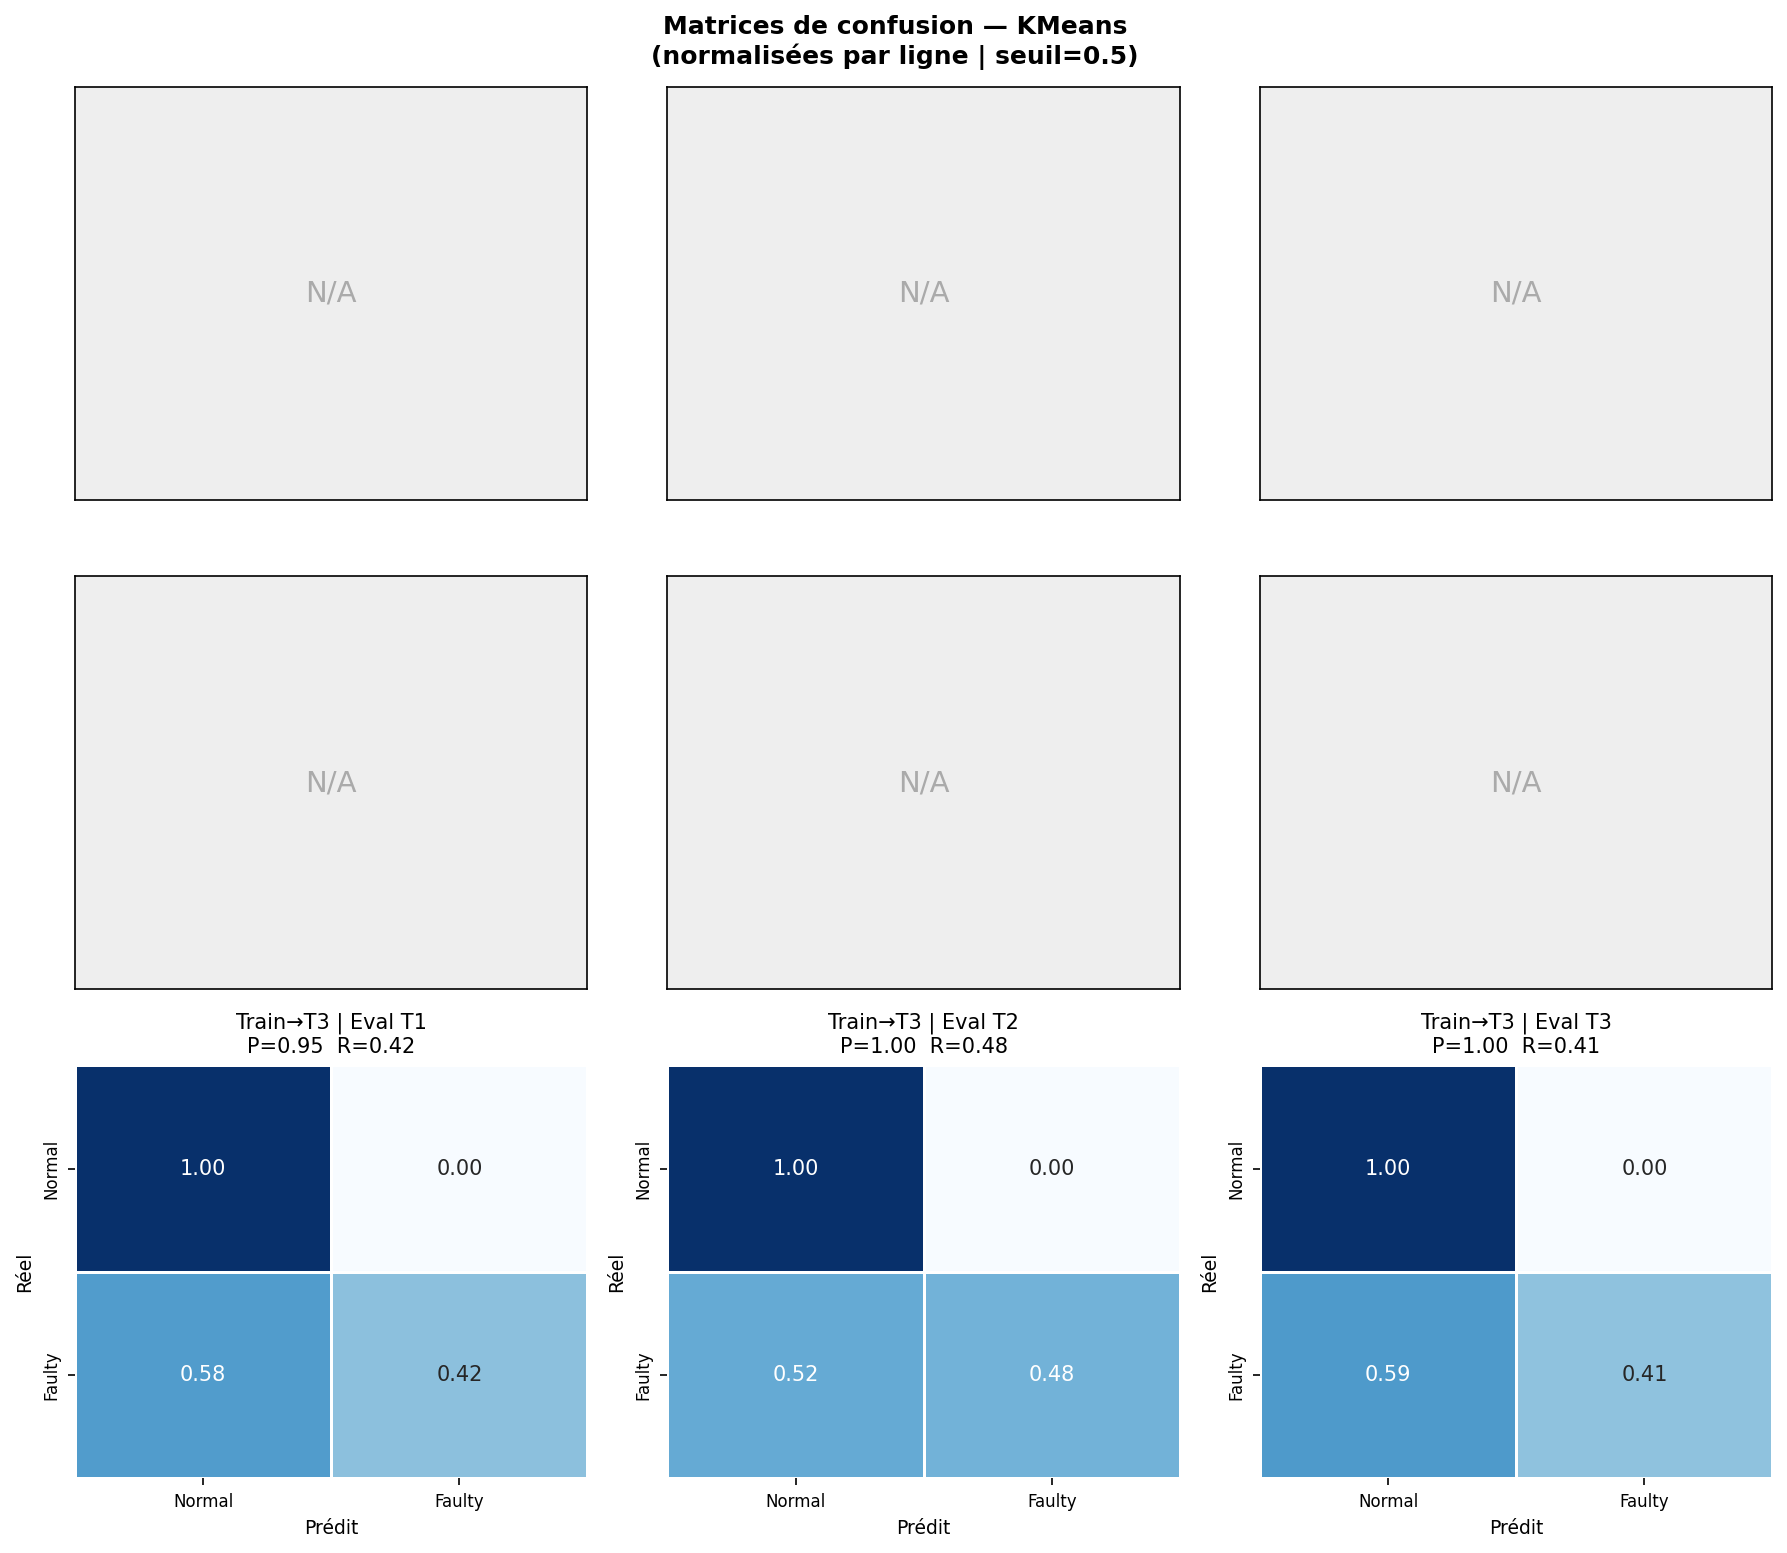

In [ ]:
fig = plot_confusion_matrix_grid(
    preds_dict,
    task_names=TASK_NAMES,
    model_name=MODEL_NAME,
)
save_figure(fig, FIGURES_DIR / "confusion_matrix_grid.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "confusion_matrix_grid.png")))

## Section 7 — Courbes AUROC par tâche (détection d'anomalie)

La distance minimale au centroïde le plus proche sert de score d'anomalie continu.  
AUROC attendu ≈ 0.9621 (moyenne des 3 tâches).

[plots] Figure saved → notebooks/figures/cl_evaluation/kmeans/monitoring/by_equipment/auroc_curve.png


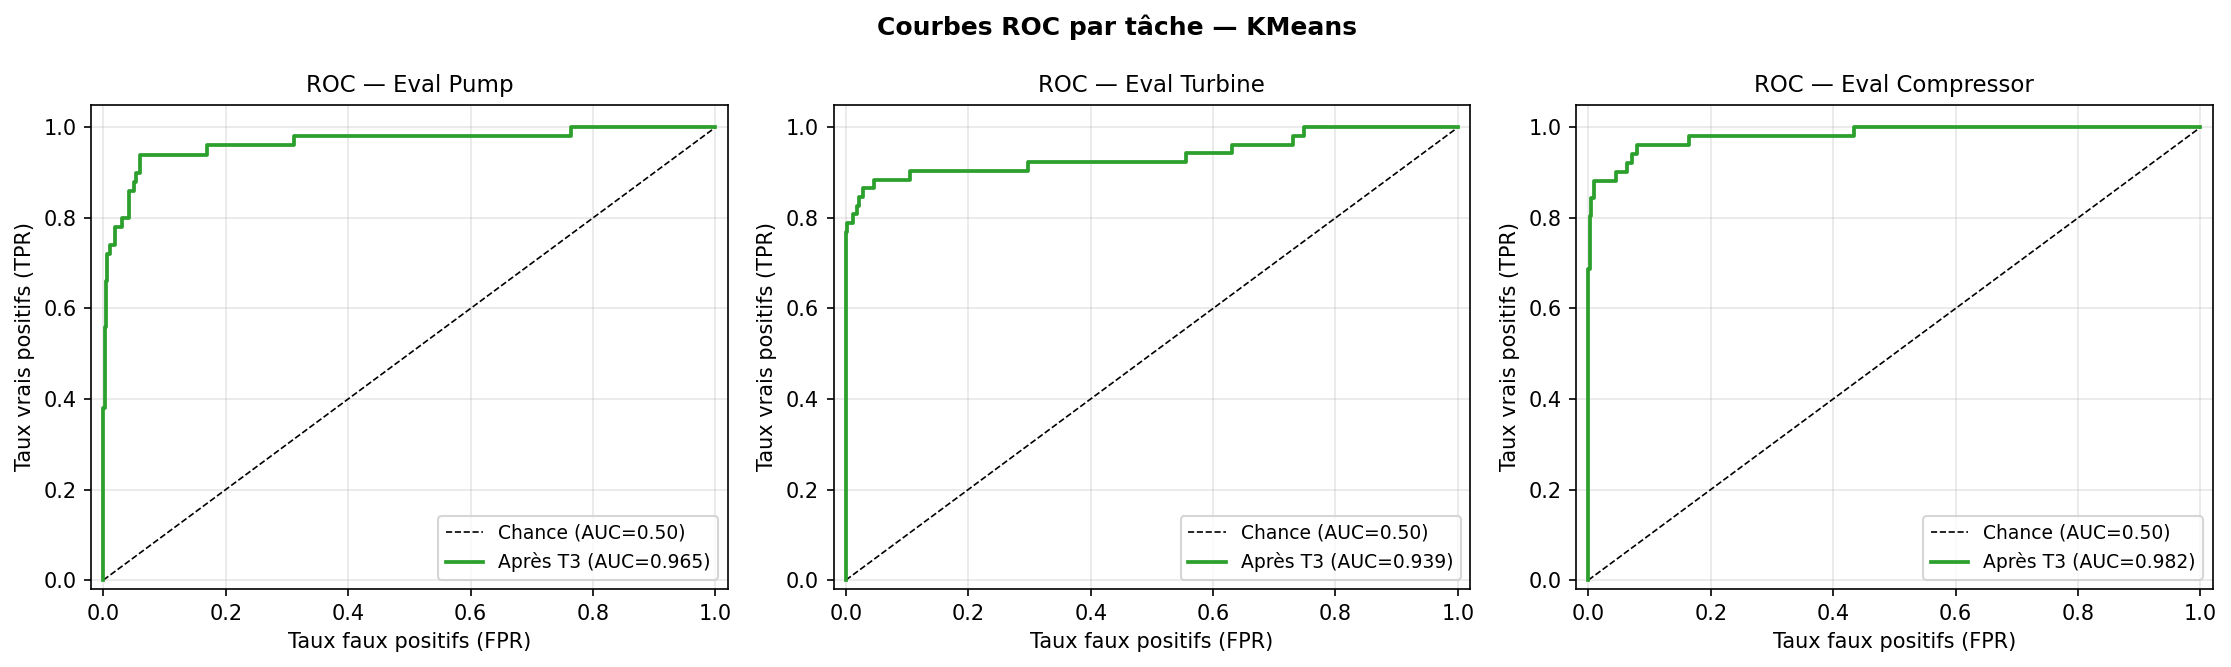

In [ ]:
fig = plot_roc_curves_per_task(
    preds_dict,
    scores_dict=scores_dict,
    task_names=TASK_NAMES,
    model_name=MODEL_NAME,
)
save_figure(fig, FIGURES_DIR / "auroc_curve.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "auroc_curve.png")))

## Section 8 — Espace des features PCA 2D (centroïdes K-Means)

Projection PCA 2D des données de validation, colorées par cluster K-Means.  
Points annotés correct (○) / incorrect (✗) selon la concordance y_true vs y_pred.  
Les centroïdes du modèle final sont affichés en étoiles noires.

> Note : le modèle pkl est l'état final (après tâche 3). Les centroïdes sont identiques pour chaque tâche.

[plots] Figure saved → notebooks/figures/cl_evaluation/kmeans/monitoring/by_equipment/feature_space_pca.png


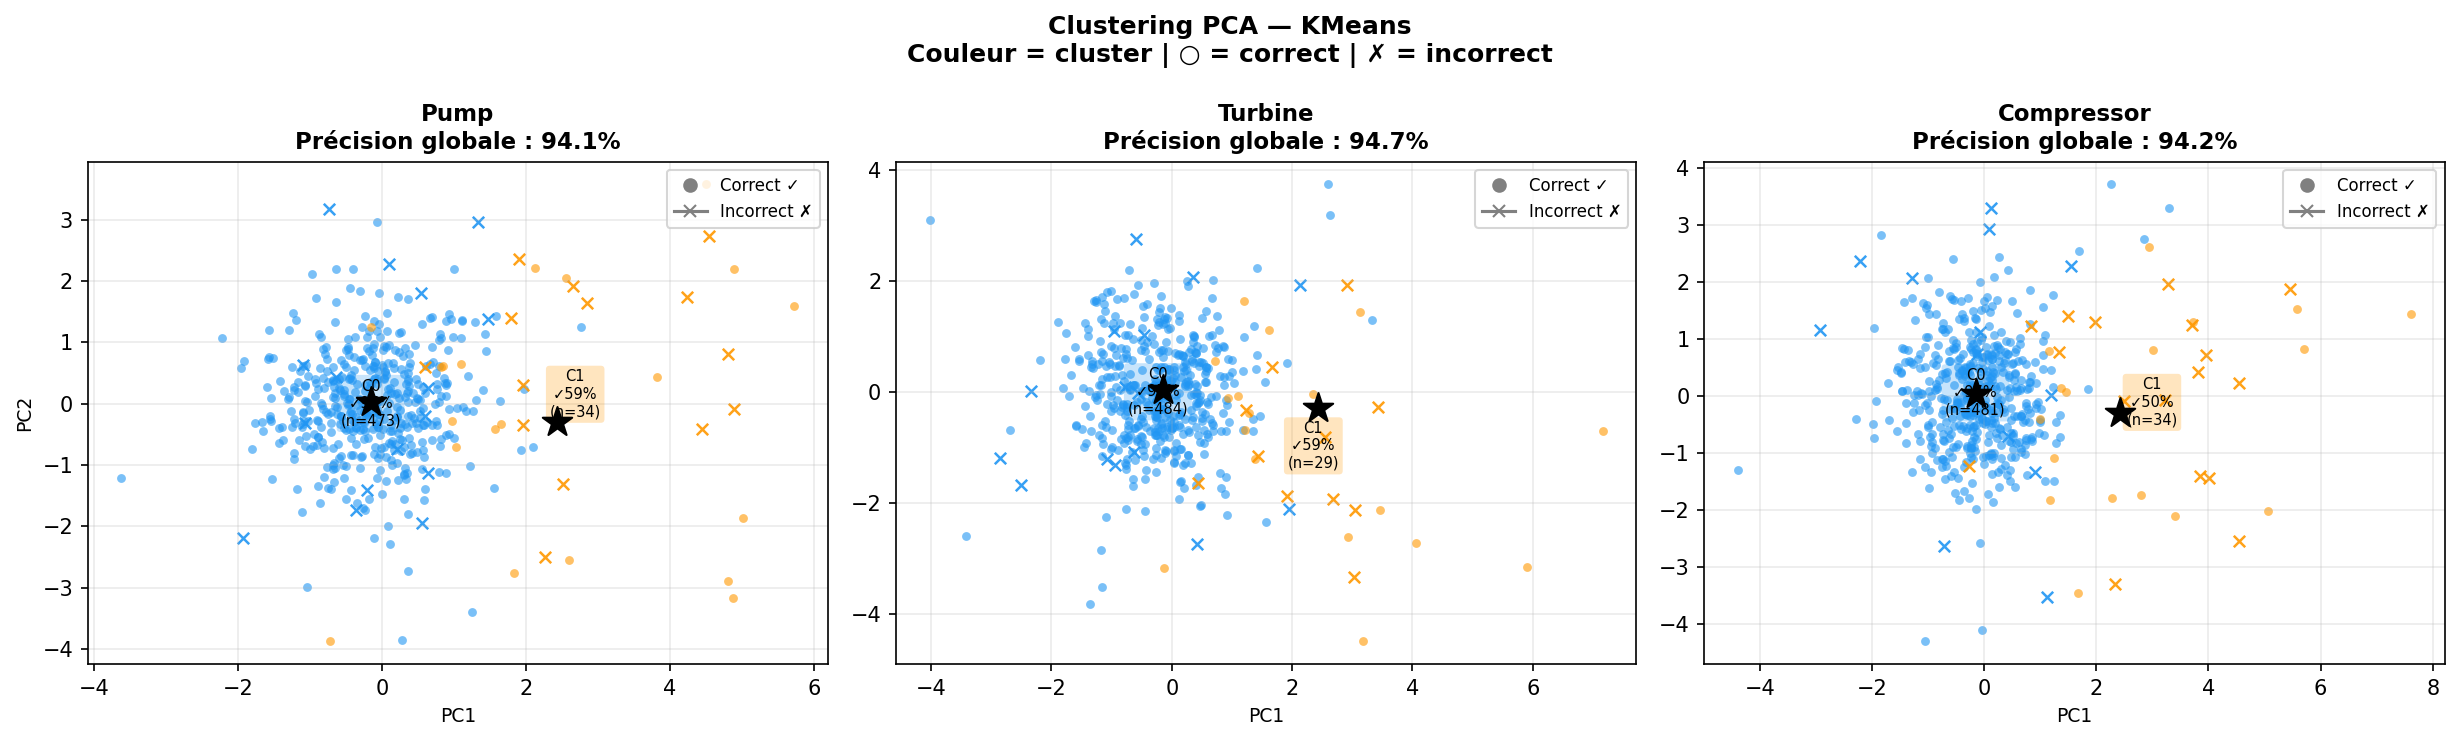

In [ ]:
# Centroïdes du modèle final (kmeans_ est le sklearn KMeans sous-jacent)
centroids_tasks = [kmeans_det.kmeans_.cluster_centers_] * T

fig = plot_clustering_with_correctness(
    X_tasks,
    y_true_tasks,
    y_pred_tasks,
    cluster_tasks,
    task_names=TASK_NAMES,
    model_name=MODEL_NAME,
    projection="pca",
    centroids_tasks=centroids_tasks,
)
save_figure(fig, FIGURES_DIR / "feature_space_pca.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "feature_space_pca.png")))

## Section 9 — Tableau récapitulatif

Valeurs attendues : AA=0.9433 | AF=0.0049 | BWT=−0.0040 | AUROC=0.9621 | RAM=5.2 Ko | Latence=0.39870 ms

> `FIXME(gap3)` : K-Means ne nécessite pas de labels à l'entraînement — avantage documenté ici :  
> économie de coût d'annotation en production industrielle (pas de labellisation de pannes requise).

In [ ]:
aa    = raw["aa"]
af    = raw["af"]
bwt   = raw["bwt"]
auroc = raw["auroc_avg"]
ram   = mem["ram_peak_bytes"] / 1024
lat   = mem["inference_latency_ms"]

print("Tableau récapitulatif (format roadmap):\n")
print("| Modèle | AA | AF | BWT | AUROC | RAM | Latence | n_params |")
print("|--------|-----|-----|-----|-------|-----|---------|----------|")
print(f"| {MODEL_NAME} | {aa:.4f} | {af:.4f} | {bwt:.4f} | {auroc:.4f} | {ram:.2f} Ko | {lat:.5f} ms | — |")

print("\n--- Vérification critères d'acceptation ---")
checks = [
    ("AA ≈ 0.9433",    abs(aa - 0.9433) < 1e-3),
    ("AF ≈ 0.0049",    abs(af - 0.0049) < 1e-3),
    ("BWT ≈ −0.0040",  abs(bwt - (-0.0040)) < 1e-3),
    ("AUROC ≈ 0.9621", abs(auroc - 0.9621) < 1e-3),
    ("RAM ≤ 64 Ko",    mem["ram_peak_bytes"] <= 65536),
    ("Latence ≤ 100 ms", lat <= 100.0),
]
for label, ok in checks:
    print(f"  {'OK' if ok else 'KO'} {label}")

figs = sorted(FIGURES_DIR.glob("*.png"))
print(f"\nFigures générées ({len(figs)}/5) : {[f.name for f in figs]}")